# Notebook 01 — Análisis Exploratorio de Datos (EDA)
## Clasificador de Noticias Falsas con Redes Neuronales Profundas

**Semana 1** | Modelado Predictivo 2026 | ESCOM-IPN

---

### Objetivos de este notebook
1. Comprender qué es el Procesamiento de Lenguaje Natural (NLP)
2. Conocer el problema de las noticias falsas y su relevancia social
3. Cargar y explorar el dataset WELFake
4. Identificar patrones, valores nulos, duplicados y distribuciones clave

## 1. ¿Qué es el Procesamiento de Lenguaje Natural (NLP)?

El **Procesamiento de Lenguaje Natural** (Natural Language Processing, NLP) es una rama de la inteligencia artificial que se enfoca en la interacción entre computadoras y el lenguaje humano.

### Ejemplos cotidianos de NLP:
- **Asistentes virtuales**: Siri, Alexa y Google Assistant entienden comandos de voz
- **Traductores automáticos**: Google Translate convierte texto entre idiomas
- **Filtros de spam**: Gmail clasifica correos como spam o legítimos
- **Autocompletado**: El teclado de tu celular predice la siguiente palabra
- **Análisis de sentimientos**: Empresas analizan opiniones en redes sociales

### ¿Por qué es difícil?
El lenguaje humano es **ambiguo**, **contextual** y **variable**. Por ejemplo:
- *"El banco está cerca"* — ¿institución financiera o asiento?
- *"No está mal"* — ¿es positivo o negativo?
- *"Voy volando"* — ¿literalmente o metafóricamente?

Las computadoras no entienden palabras directamente; necesitamos **representar el texto como números** para poder procesarlo con modelos matemáticos.

## 2. Tipos de Clasificación de Texto

La clasificación de texto es una tarea fundamental en NLP. Existen varios tipos:

| Tipo | Descripción | Ejemplo |
|------|-------------|----------|
| **Binaria** | Dos clases posibles | Spam vs. No spam |
| **Multiclase** | Más de dos clases, una por documento | Categoría de noticia: deportes, política, tecnología |
| **Multilabel** | Múltiples etiquetas por documento | Un artículo puede ser "tecnología" Y "negocios" |

### Nuestro proyecto: Clasificación Binaria
Clasificaremos noticias en dos categorías:
- **0 = Real** (noticia verdadera)
- **1 = Fake** (noticia falsa)

Este es un problema de **clasificación binaria de texto**, similar a la detección de spam.

## 3. El Problema de las Noticias Falsas

### ¿Por qué es relevante?
Las noticias falsas (fake news) son un problema creciente con impacto real:
- Influyen en **elecciones** y decisiones políticas
- Generan **pánico social** (ej: desinformación durante pandemias)
- Erosionan la **confianza** en medios de comunicación
- Se propagan **6 veces más rápido** que las noticias verdaderas en redes sociales (Vosoughi et al., 2018)

### ¿Puede una máquina detectar noticias falsas?
La detección automática es un campo activo de investigación. Los enfoques van desde:
- **Métodos clásicos**: Term Frequency-Inverse Document Frequency (TF-IDF) + modelos lineales (como la Regresión Logistica). ~93-94% accuracy.
- **Redes neuronales**: Convolutional Neural Networks (CNN), Long Short-Term Memory (LSTM). ~96-97%.
- **Transformers**: Bidirectional Encoder Representations from Transformers (BERT). ~98.7%

En este proyecto construiremos modelos desde los más simples hasta redes profundas, y compararemos su rendimiento.

### Entendiendo los errores del clasificador: VP, VN, FP y FN

Cuando un modelo clasifica noticias, cada prediccion cae en una de cuatro categorias. Entender estas categorias es fundamental para evaluar que tan bien funciona nuestro clasificador y cuales son las **consecuencias reales** de sus errores.

En nuestro contexto: **Positivo = Fake (1)** y **Negativo = Real (0)**.

| Resultado | Abreviatura | Significado en Fake News | Ejemplo |
|-----------|-------------|--------------------------|---------|
| **Verdadero Positivo (VP)** | TP | El modelo dice "Fake" y **si es fake** | Una noticia inventada sobre un politico es correctamente identificada como falsa |
| **Verdadero Negativo (VN)** | TN | El modelo dice "Real" y **si es real** | Un reportaje verificado de Reuters es correctamente identificado como real |
| **Falso Positivo (FP)** | FP | El modelo dice "Fake" pero **es real** | Una noticia legitima es censurada por error al ser marcada como falsa |
| **Falso Negativo (FN)** | FN | El modelo dice "Real" pero **es fake** | Una noticia falsa pasa el filtro y se difunde como si fuera verdadera |

#### ¿Por que importan estos errores?

No todos los errores tienen el mismo costo. En el contexto de noticias falsas:

- **Falso Positivo (FP)** — *Censurar una noticia real*: Se bloquea informacion verdadera. Esto afecta la **libertad de prensa** y puede generar desconfianza en el sistema de deteccion. Imagina que un medio serio publica una investigacion y el modelo la marca como fake.

- **Falso Negativo (FN)** — *Dejar pasar una noticia falsa*: La desinformacion se propaga sin filtro. Esto puede causar **dano social real**: panico, decisiones erroneas, manipulacion de opiniones. Imagina que una noticia falsa sobre una emergencia de salud pasa el filtro y se viraliza.

#### Representacion visual: Matriz de Confusion

```
                    Prediccion del Modelo
                    Fake (1)      Real (0)
                 ┌────────────┬────────────┐
  Real   Fake    │     VP     │     FN     │
  Label  (1)     │  Acierto   │   Error    │
                 ├────────────┼────────────┤
         Real    │     FP     │     VN     │
         (0)     │   Error    │  Acierto   │
                 └────────────┴────────────┘
```

> **Pregunta para reflexionar:** En un sistema de deteccion de fake news desplegado en una red social, ¿que tipo de error consideras mas grave: un FP (censurar noticias reales) o un FN (dejar pasar noticias falsas)? La respuesta depende del contexto y no hay una unica respuesta correcta — lo importante es ser consciente del trade-off.

## 4. Dataset WELFake

Usaremos el dataset **WELFake** (Word Embedding over Linguistic Features for Fake News Detection), publicado por Verma et al. (2021).

| Atributo | Detalle |
|----------|----------|
| Total de muestras | 72,134 noticias |
| Clases | 0 = Real, 1 = Fake (balanceado) |
| Columnas | `title`, `text`, `label` |
| Origen | Combinación de Kaggle, McIntire, Reuters y BuzzFeed |
| Idioma | Inglés |

**Referencia:** Verma, P. et al. (2021). *WELFake: Word Embedding over Linguistic Features for Fake News Detection*. IEEE Transactions on Computational Social Systems.

### Descarga del dataset
1. Ve a: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
2. Descarga el archivo `WELFake_Dataset.csv`
3. Colócalo en la carpeta `../data/WELFake_Dataset.csv`

---
## 5.  Analisis Exploratorio

Realizaremos un EDA completo paso a paso usando el dataset **20 Newsgroups** de scikit-learn. Seleccionaremos 2 categorias (Baseball vs Space) para simular un problema de clasificacion binaria, exactamente como haremos despues con el dataset de noticias falsas.



### 5.1 El dataset 20 Newsgroups y nuestro problema de clasificacion

#### Que es 20 Newsgroups?

El dataset **20 Newsgroups** es uno de los conjuntos de datos mas clasicos en NLP y clasificacion de texto. Fue recopilado originalmente por Ken Lang y contiene aproximadamente **18,846 documentos** (posts de foros de discusion de Usenet) distribuidos en **20 categorias tematicas**.

Estas 20 categorias abarcan temas diversos:

| Grupo | Categorias |
|-------|------------|
| **Computacion** | comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x |
| **Ciencia** | sci.crypt, sci.electronics, sci.med, sci.space |
| **Deportes** | rec.sport.baseball, rec.sport.hockey |
| **Recreacion** | rec.autos, rec.motorcycles |
| **Religion** | soc.religion.christian, talk.religion.misc, alt.atheism |
| **Politica** | talk.politics.misc, talk.politics.guns, talk.politics.mideast |
| **Ventas** | misc.forsale |

El dataset esta disponible directamente en **scikit-learn** (`sklearn.datasets.fetch_20newsgroups`), lo que lo hace ideal para practicar sin necesidad de descargar archivos externos.

#### Por que seleccionamos Baseball y Space?

De las 20 categorias disponibles, elegimos especificamente dos:

- **`rec.sport.baseball`** (label=0): Discusiones sobre beisbol de las Grandes Ligas (MLB). Los posts incluyen estadisticas de jugadores, resultados de juegos, debates sobre trades, predicciones de temporada y discusiones sobre reglas del deporte. Vocabulario tipico: *game, team, players, hit, run, season, pitch, bat*.

- **`sci.space`** (label=1): Discusiones sobre ciencia espacial y astronomia. Los posts cubren misiones de la NASA, lanzamientos de cohetes, telescopios, fisica orbital, exploracion planetaria y noticias de la industria aeroespacial. Vocabulario tipico: *space, orbit, launch, NASA, shuttle, satellite, earth, moon*.

Estas dos categorias fueron elegidas porque:

1. **Vocabulario claramente diferente**: beisbol y ciencia espacial usan terminologia muy distinta, lo que facilita la clasificacion y permite observar patrones claros en el EDA
2. **Simulan un problema binario**: al tomar solo 2 de las 20 categorias, creamos un problema de clasificacion binaria identico en estructura a nuestro proyecto final (Real vs Fake)
3. **Dataset pequeño (~2,000 docs)**: permite ejecutar todo el EDA rapidamente antes de trabajar con el dataset WELFake completo (72,134 noticias)
4. **Sin ambiguedad tematica**: a diferencia de categorias como `talk.politics.misc` vs `talk.politics.guns` que comparten vocabulario, Baseball y Space son temas lo suficientemente distintos para que un clasificador logre buena separacion

> **Nota**: Al cargar el dataset usamos `remove=("headers", "footers", "quotes")` para eliminar metadatos de los posts (encabezados de email, firmas, texto citado). Esto obliga al modelo a clasificar por el **contenido real** del texto, no por pistas artificiales como la direccion de email del autor.

#### La Matriz de Confusion para Baseball vs Space

En la seccion 3 vimos la matriz de confusion para noticias falsas. Ahora veamos como se interpreta para nuestro dataset de practica, donde:
- **Positivo = Space (1)**
- **Negativo = Baseball (0)**

```
                      Prediccion del Modelo
                      Space (1)     Baseball (0)
                   +--------------+--------------+
  Real    Space    |     VP       |     FN       |
  Label   (1)      |  Acierto     |   Error      |
                   +--------------+--------------+
         Baseball  |     FP       |     VN       |
         (0)       |   Error      |  Acierto     |
                   +--------------+--------------+
```

| Resultado | Significado en Baseball vs Space | Ejemplo concreto |
|-----------|----------------------------------|------------------|
| **VP** (Verdadero Positivo) | El modelo dice "Space" y **si es Space** | Un post sobre el lanzamiento del telescopio Hubble es correctamente clasificado como Space |
| **VN** (Verdadero Negativo) | El modelo dice "Baseball" y **si es Baseball** | Un post sobre las estadisticas de bateo de Ken Griffey Jr. es correctamente clasificado como Baseball |
| **FP** (Falso Positivo) | El modelo dice "Space" pero **es Baseball** | Un post de Baseball que menciona "Houston" (Astros) es confundido con Space (Houston = ciudad de la NASA) |
| **FN** (Falso Negativo) | El modelo dice "Baseball" pero **es Space** | Un post de Space que usa lenguaje informal como "home run de la NASA" es confundido con Baseball |

#### Que errores serian mas problematicos aqui?

A diferencia del caso de noticias falsas (donde los errores tienen consecuencias sociales graves), en este dataset de practica los errores son **simetricos**: confundir Baseball con Space no es inherentemente peor que confundir Space con Baseball. Por eso:

- Usamos **accuracy** como metrica principal (proporcion de aciertos totales)
- El dataset esta **balanceado** (~50/50), asi que accuracy es una metrica confiable
- En el proyecto final con noticias falsas, tendremos que considerar si los FP y FN tienen **costos asimetricos**

#### Ejemplo numerico: interpretando una matriz de confusion

Supongamos que nuestro modelo clasifica los ~1,912 documentos y obtiene estos resultados:

```
                      Prediccion del Modelo
                      Space (1)     Baseball (0)
                   +--------------+--------------+
  Real    Space    |     912      |      42      |  954 docs de Space
  Label   (1)      |     (VP)     |     (FN)     |
                   +--------------+--------------+
         Baseball  |      35      |     923      |  958 docs de Baseball
         (0)       |     (FP)     |     (VN)     |
                   +--------------+--------------+
                        947            965         Total: 1,912
```

De esta matriz podemos calcular:
- **Accuracy** = (VP + VN) / Total = (912 + 923) / 1912 = **95.97%**
- **Precision (Space)** = VP / (VP + FP) = 912 / 947 = **96.30%** — De todo lo que el modelo etiqueto como Space, el 96.3% realmente lo era
- **Recall (Space)** = VP / (VP + FN) = 912 / 954 = **95.60%** — De todos los documentos que realmente son Space, el modelo detecto el 95.6%
- **Errores**: 42 posts de Space fueron clasificados como Baseball (FN), y 35 posts de Baseball fueron clasificados como Space (FP)

Los 35 falsos positivos podrian ser posts de Baseball que mencionan temas como "Houston Astros" (Houston = ciudad de la NASA) o "fly ball" (fly = volar). Los 42 falsos negativos podrian ser posts de Space con lenguaje coloquial o referencias deportivas.

> **Conexion con el proyecto final:** Todo lo que practiquemos aqui (EDA, limpieza, visualizacion) lo aplicaremos al dataset WELFake. La estructura es identica: dos clases, texto como entrada, clasificacion binaria. Solo cambia la escala (2K vs 72K documentos) y la relevancia social del problema.

### 5.2 Instalacion e importacion de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.datasets import fetch_20newsgroups
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Librerias importadas correctamente.')

Librerias importadas correctamente.


### 5.3 Carga del dataset

**Que haremos?** Cargar el dataset 20 Newsgroups con 2 categorias (Baseball y Space) y organizarlo en un DataFrame de pandas.

**Por que?** Antes de cualquier analisis, debemos confirmar que los datos se cargaron correctamente: numero de filas, columnas y tipos de datos.

In [2]:
# Cargar 2 categorias: deportes (Baseball) vs ciencia (Space)
categories = ['rec.sport.baseball', 'sci.space']
newsgroups = fetch_20newsgroups(
    subset='all', categories=categories,
    remove=('headers', 'footers', 'quotes'), random_state=42
)

# Crear DataFrame (similar a como cargaremos WELFake)
df = pd.DataFrame({
    'text': newsgroups.data,
    'label': newsgroups.target
})
class_names = {0: 'Baseball', 1: 'Space'}

# Verificar forma del dataset
print(f'Forma del dataset: {df.shape}')
print(f'Numero de filas: {df.shape[0]:,}')
print(f'Numero de columnas: {df.shape[1]}')
print(f'\nColumnas: {list(df.columns)}')
print(f'\nTipos de datos:')
print(df.dtypes)
print(f'\nPrimeras 5 filas:')
df.head()

Forma del dataset: (1981, 2)
Numero de filas: 1,981
Numero de columnas: 2

Columnas: ['text', 'label']

Tipos de datos:
text       str
label    int64
dtype: object

Primeras 5 filas:


,text,label
0,\nDo you really have *that* much information o...,0
1,\n ^^^^^^\n\n\tSure they might. ...,0
2,------------------------- Original Article ---...,0
3,"\nNot really, though I wouldn't personally say...",0
4,\nCan anybody name a player who was 'rushed' t...,0


**Reflexion:** El dataset tiene ~1,981 documentos de texto con etiquetas binarias (0=Baseball, 1=Space). Es mucho mas pequeno que WELFake (72K), lo que nos permite explorar rapidamente.

### 5.4 Distribucion de clases

**Que haremos?** Contar cuantos documentos son de Baseball (0) y cuantos de Space (1), y visualizarlo.

**Por que?** Un dataset **balanceado** (misma cantidad de cada clase) simplifica el entrenamiento. Si estuviera desbalanceado, necesitariamos tecnicas especiales como oversampling o ajuste de pesos.

label
0    994
1    987
Name: count, dtype: int64
Distribucion de clases:
  Baseball (label=0): 994 (50.2%)
  Space (label=1): 987 (49.8%)


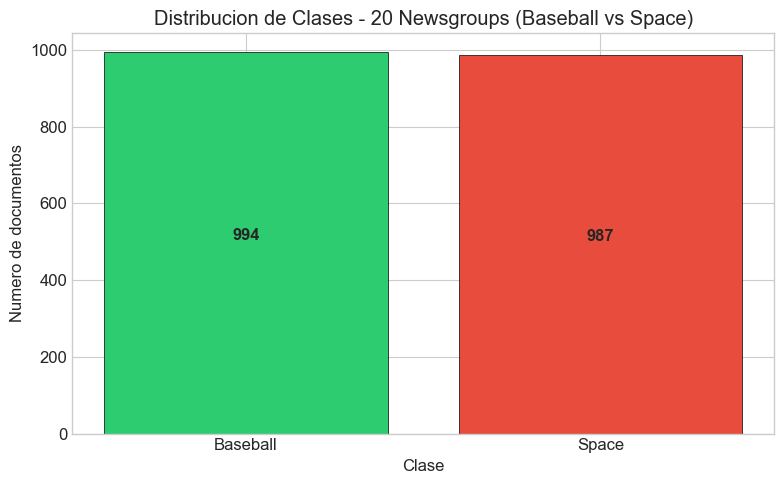

In [3]:
# Distribucion de clases
class_counts = df['label'].value_counts()

print(class_counts)
print('Distribucion de clases:')
for label, count in class_counts.items():
    name = class_names[label]
    print(f'  {name} (label={label}): {count:,} ({count/len(df)*100:.1f}%)')

# Grafico de barras
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [class_names[i] for i in class_counts.index],
    class_counts.values,
    color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5
)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Clase')
ax.set_ylabel('Numero de documentos')
ax.set_title('Distribucion de Clases - 20 Newsgroups (Baseball vs Space)')
plt.tight_layout()
plt.show()

**Reflexion:** El dataset esta bastante balanceado (~50/50). Esto es ideal para clasificacion binaria.

### 5.5 Distribucion de longitudes de texto

**Que haremos?** Calcular cuantas palabras tiene cada documento y visualizar las distribuciones por clase.

**Por que?** La longitud del texto es crucial para decidir:
- El valor de `max_len` para la red neuronal
- Si hay textos muy cortos o muy largos que podrian ser problematicos

In [4]:
# Calcular longitudes (en numero de palabras)
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))

# Estadisticas descriptivas
print('=== Longitud del TEXTO (en palabras) ===')
print(f"  Media:   {df['text_len'].mean():.1f}")
print(f"  Mediana: {df['text_len'].median():.1f}")
print(f"  Minimo:  {df['text_len'].min()}")
print(f"  Maximo:  {df['text_len'].max()}")

# Estadisticas por clase
print(f'\n=== Estadisticas por clase ===')
for label, name in class_names.items():
    subset = df[df['label'] == label]['text_len']
    print(f'  {name}: media={subset.mean():.1f}, mediana={subset.median():.1f}, '
          f'min={subset.min()}, max={subset.max()}')

=== Longitud del TEXTO (en palabras) ===
  Media:   157.3
  Mediana: 78.0
  Minimo:  0
  Maximo:  9113

=== Estadisticas por clase ===
  Baseball: media=124.9, mediana=69.0, min=0, max=2479
  Space: media=189.9, mediana=85.0, min=0, max=9113


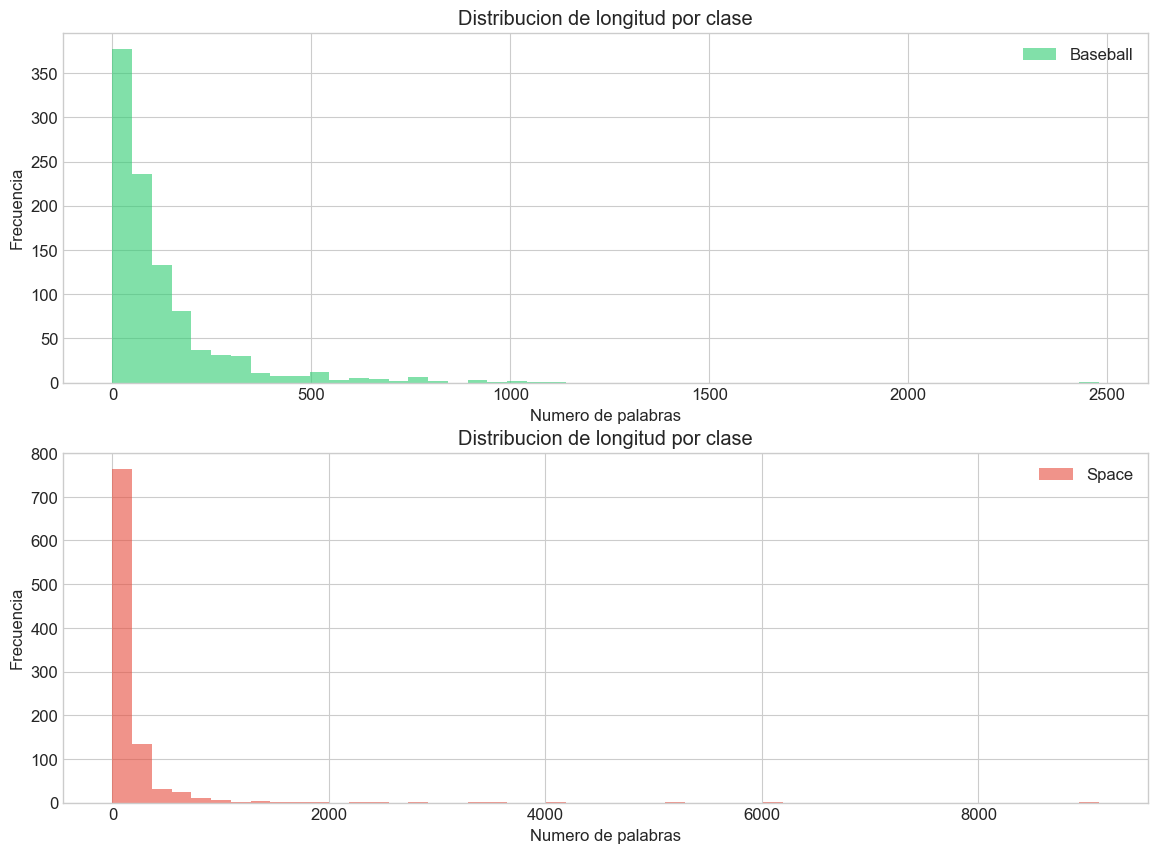

In [5]:
# Histogramas de longitudes por clase
fig, axes = plt.subplots(2,1,figsize=(14, 10))

# Histograma superpuesto
#for label, name in class_names.items():
#    subset = df[df['label'] == label]['text_len']
#    axes[0].hist(subset, bins=50, alpha=0.6, label=name,
#                 color='#2ecc71' if label == 0 else '#e74c3c')

subset = df[df['label'] == 0]['text_len']
axes[0].hist(subset, bins=50, alpha=0.6, label='Baseball',color='#2ecc71')
axes[0].set_xlabel('Numero de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de longitud por clase')
axes[0].legend()

subset = df[df['label'] == 1]['text_len']
axes[1].hist(subset, bins=50, alpha=0.6, label='Space',color='#e74c3c')
axes[1].set_xlabel('Numero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de longitud por clase')
axes[1].legend()



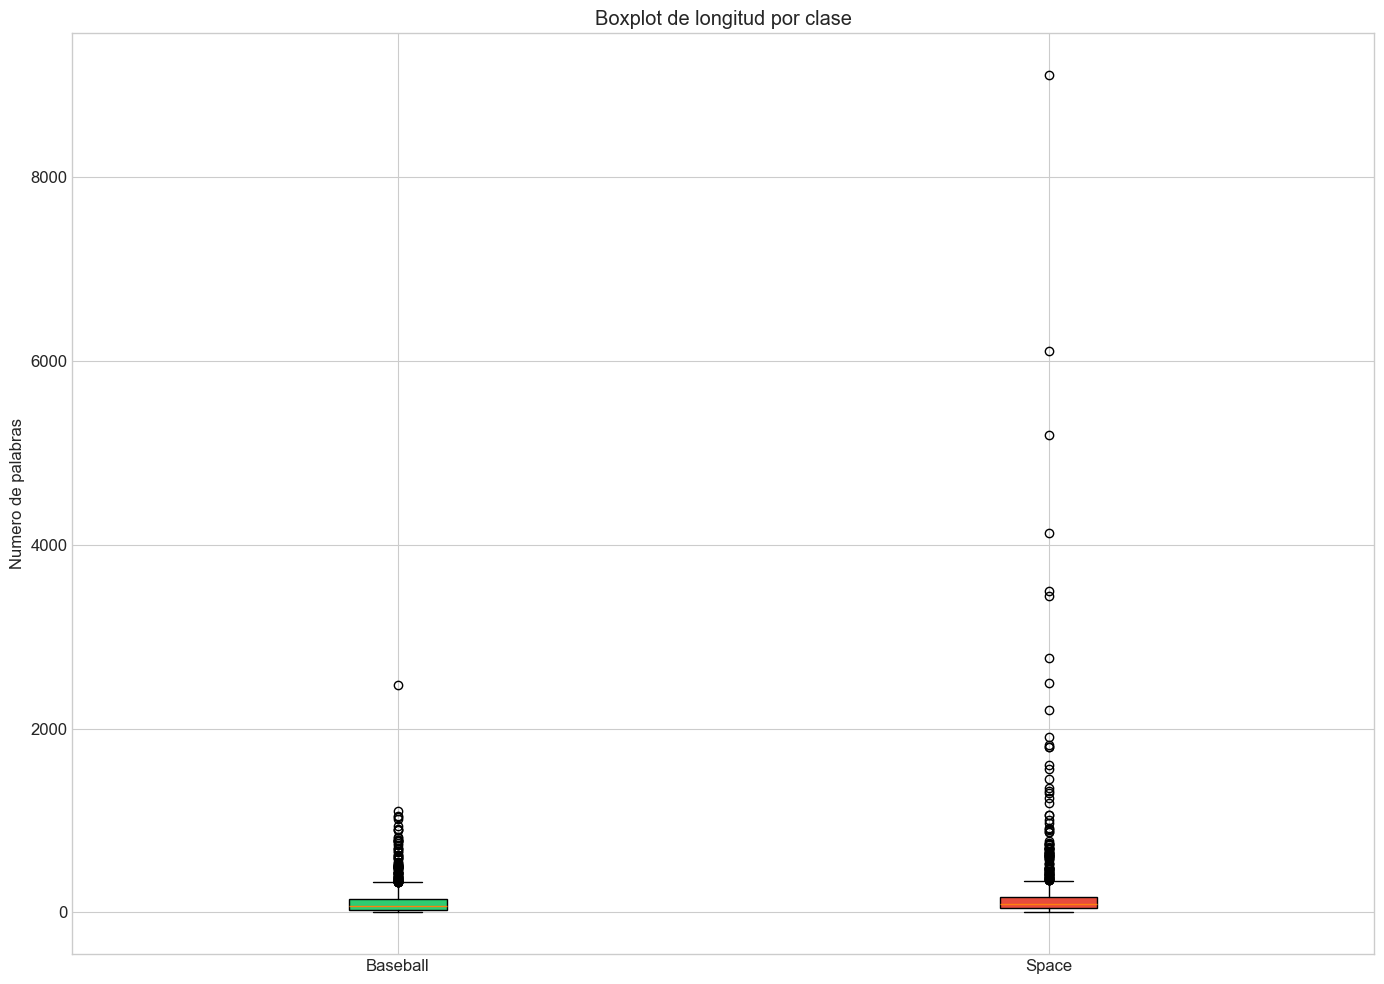

In [6]:
# Boxplot por clase
fig, axes = plt.subplots(figsize=(14, 10))

data_by_class = [df[df['label'] == l]['text_len'].values for l in class_names]
bp = axes.boxplot(data_by_class, labels=list(class_names.values()),
                     patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes.set_ylabel('Numero de palabras')
axes.set_title('Boxplot de longitud por clase')

plt.tight_layout()
plt.show()

**Reflexion:**
- Hay diferencias de longitud entre documentos de Baseball y Space?
- Si usaramos `max_len=200` tokens, que porcentaje de textos se truncarian?

In [ ]:
# Que porcentaje de textos superan 200 tokens?
pct_over_200 = (df['text_len'] > 200).sum() / len(df) * 100
print(f'Textos con mas de 200 palabras: {pct_over_200:.1f}%')
print(f'Textos con 200 palabras o menos: {100 - pct_over_200:.1f}%')

# Percentiles utiles para elegir max_len
for p in [50, 75, 90, 95, 99]:
    val = np.percentile(df['text_len'], p)
    print(f'  Percentil {p}: {val:.0f} palabras')

### 5.6 Deteccion y manejo de valores nulos

**Que haremos?** Identificar filas con valores faltantes (NaN/null).

**Por que?** Los valores nulos causan errores en el preprocesamiento. Debemos decidir si:
- **Eliminar** las filas con nulos (si son pocas)
- **Rellenar** con un texto vacio o un marcador especial

La decision debe estar **justificada** y documentada.

In [ ]:
# Deteccion de valores nulos
print('Valores nulos por columna:')
null_counts = df.isnull().sum()
print(null_counts)
print(f'\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}')
print(f'Porcentaje del dataset: {df.isnull().any(axis=1).sum() / len(df) * 100:.2f}%')

# Revisar si hay textos vacios (no NaN, pero sin contenido)
empty_texts = (df['text'].str.strip() == '').sum()
print(f'\nTextos vacios (cadena vacia): {empty_texts}')

In [ ]:
# Estrategia: si hay nulos o textos vacios, los manejamos
rows_before = len(df)

# Rellenar nulos con cadena vacia
df['text'] = df['text'].fillna('')

# Eliminar filas con texto vacio (no aportan informacion)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)

rows_after = len(df)
print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')

**Decision documentada:** Se eliminaron las filas con texto vacio porque no aportan informacion util para el analisis ni para el entrenamiento de modelos.

### 5.7 Deteccion y manejo de duplicados

**Que haremos?** Buscar filas duplicadas y eliminarlas.

**Por que?** Los duplicados pueden:
- **Inflar metricas**: si el mismo texto aparece en train y test, el modelo "memoriza"
- **Sesgar el entrenamiento**: el modelo ve mas veces ciertos ejemplos

In [ ]:
# Deteccion de duplicados
duplicates = df.duplicated(subset=['text'], keep='first')
n_duplicates = duplicates.sum()
print(f'Filas duplicadas encontradas: {n_duplicates:,}')
print(f'Porcentaje del dataset: {n_duplicates / len(df) * 100:.2f}%')

if n_duplicates > 0:
    print(f'\nEjemplo de fila duplicada:')
    dup_idx = duplicates[duplicates].index[0]
    print(f'  Texto: {df.loc[dup_idx, "text"][:100]}...')
    print(f'  Clase: {class_names[df.loc[dup_idx, "label"]]}')

In [ ]:
# Eliminar duplicados
rows_before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
rows_after = len(df)

print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')

# Verificar impacto en balance de clases
print(f'\nDistribucion de clases despues de eliminar duplicados:')
for label, count in df['label'].value_counts().items():
    name = class_names[label]
    print(f'  {name}: {count:,} ({count/len(df)*100:.1f}%)')

In [ ]:
# Distribucion de clases
class_counts = df['label'].value_counts()

print('Distribucion de clases:')
for label, count in class_counts.items():
    name = class_names[label]
    print(f'  {name} (label={label}): {count:,} ({count/len(df)*100:.1f}%)')

# Grafico de barras
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [class_names[i] for i in class_counts.index],
    class_counts.values,
    color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5
)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Clase')
ax.set_ylabel('Numero de documentos')
ax.set_title('Distribucion de Clases - 20 Newsgroups (Baseball vs Space)')
plt.tight_layout()
plt.show()

**Reflexion:** La eliminacion de duplicados afecto significativamente el balance de clases?

### 5.8 Nubes de palabras por clase

**Que haremos?** Generar una nube de palabras para Baseball y otra para Space.

**Por que?** Las nubes de palabras muestran rapidamente que palabras son mas frecuentes en cada clase, dandonos intuicion sobre:
- Usan vocabulario diferente las dos categorias?
- Hay palabras claramente indicativas de una clase?

In [ ]:
# Nubes de palabras
fig, axes = plt.subplots(2, 1, figsize=(20, 15))

colors_map = {0: 'Greens', 1: 'Reds'}
for idx, (label, name) in enumerate(class_names.items()):
    text = ' '.join(df[df['label'] == label]['text'].astype(str).values)
    wordcloud = WordCloud(
        width=800, height=400,
        max_words=100,
        background_color='white',
        colormap=colors_map[label],
        random_state=42
    ).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras - {name}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

**Reflexion:**
- Que palabras dominan en los articulos de Baseball? Y en los de Space?
- Hay diferencias claras entre ambas nubes?
- Estas diferencias podrian ayudar a un modelo a distinguir entre clases?
- Nota: las nubes muestran frecuencia bruta, no importancia para clasificacion.

### 5.9 Top palabras mas frecuentes por clase

**Que haremos?** Contar las palabras mas frecuentes en cada clase y compararlas.

**Por que?** Complementa las nubes de palabras con datos exactos. Nos permite ver si hay vocabulario compartido o exclusivo de cada categoria.

In [ ]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (label, name) in enumerate(class_names.items()):
    # Contar todas las palabras de la clase
    all_text = ' '.join(df[df['label'] == label]['text'].str.lower().values)
    word_counts = Counter(all_text.split())

    # Top 20 (excluyendo stopwords comunes)
    stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
                 'to', 'of', 'in', 'for', 'and', 'on', 'that', 'it', 'with',
                 'as', 'at', 'by', 'from', 'or', 'this', 'but', 'not', 'have',
                 'has', 'had', 'i', 'he', 'she', 'they', 'we', 'you', 'my',
                 'his', 'her', 'its', 'our', 'their', 'if', 'do', 'did', 'would',
                 'will', 'can', 'just', 'about', 'so', 'than', 'no', 'all'}
    filtered = {w: c for w, c in word_counts.items()
                if w not in stopwords and len(w) > 2}
    top_20 = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:20]
    words, counts = zip(*top_20)

    color = '#2ecc71' if label == 0 else '#e74c3c'
    axes[idx].barh(range(len(words)), counts[::-1], color=color, edgecolor='black', linewidth=0.5)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words[::-1])
    axes[idx].set_xlabel('Frecuencia')
    axes[idx].set_title(f'Top 20 palabras - {name}')

plt.tight_layout()
plt.show()

---
## 6. Resumen y Proximos Pasos

### Lo que aprendimos:
- El NLP transforma texto en representaciones numericas para que los modelos puedan procesarlo
- Practicamos un EDA completo sobre un dataset pequeno (Baseball vs Space)
- Identificamos y manejamos valores nulos y duplicados
- Las distribuciones de longitud nos ayudan a elegir `max_len`
- Las nubes de palabras revelan vocabulario distintivo por clase

### Siguiente paso

La **implementacion completa del EDA** con el dataset real **WELFake** (72,134 noticias) se encuentra en el notebook **`01_EDAImplementacion.ipynb`**, donde:
- Cargaremos y exploraremos el dataset WELFake
- Aplicaremos las mismas tecnicas de EDA que practicamos aqui
- Analizaremos titulos, textos, nulos, duplicados y nubes de palabras

### Proximo notebook (02_Baselines):
- Construiremos un pipeline de limpieza de texto
- Implementaremos baselines clasicos: TF-IDF + Logistic Regression, SVM, Naive Bayes, Decision Tree
- Evaluaremos con metricas apropiadas (F1, Precision, Recall)
- Estos baselines seran nuestro punto de referencia para la red neuronal

---
## Reto Semanal 1: EDA del Dataset de Noticias Falsas (WELFake)

**Objetivo:** Aplicar todas las tecnicas de EDA que practicamos con el dataset pequeno al dataset real de noticias falsas **WELFake** (72,134 noticias).

### Instrucciones:
1. Descarga el dataset de Kaggle: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
2. Colocalo en `../data/WELFake_Dataset.csv`

### Entregables (completa el codigo en las celdas siguientes):

| # | Tarea | Descripcion |
|---|-------|-------------|
| 1 | Carga y exploracion | Verifica forma, columnas, tipos de datos, primeras filas |
| 2 | Distribucion de clases | Grafica de barras con conteos. Esta balanceado? |
| 3 | Longitudes de texto | Histogramas por clase para `title` y `text`. Calcula media, mediana, max |
| 4 | Valores nulos | Detecta, decide estrategia (eliminar o rellenar) y **documenta tu decision** |
| 5 | Duplicados | Detecta, elimina y verifica impacto en el balance de clases |
| 6 | Nubes de palabras | Una nube para noticias Reales y otra para Falsas |
| 7 | Pregunta | Que porcentaje de textos se truncarian con `max_len=200`? |

### Criterios de evaluacion:
- Codigo funcional sin errores
- Graficas claras con titulos y etiquetas
- Decisiones documentadas y justificadas en celdas markdown

In [49]:
# RETO 1.1 — Carga el dataset WELFake
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud, STOPWORDS

# Carga el CSV
df = pd.read_csv('../data/WELFake_Dataset.csv')

# Elimina la columna 'Unnamed: 0' si existe
for i in df.columns:
    if i == 'Unnamed: 0':
        df = df.drop(columns=[i])
# Muestra forma, columnas, tipos de datos y primeras 5 filas
print(df.shape)

print('\n', df.columns)

print('\n', df.head(5))

(72134, 3)

 Index(['title', 'text', 'label'], dtype='object')

                                                title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                NaN   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3  Bobby Jindal, raised Hindu, uses story of Chri...   
4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  


label
1    37106
0    35028
Name: count, dtype: int64


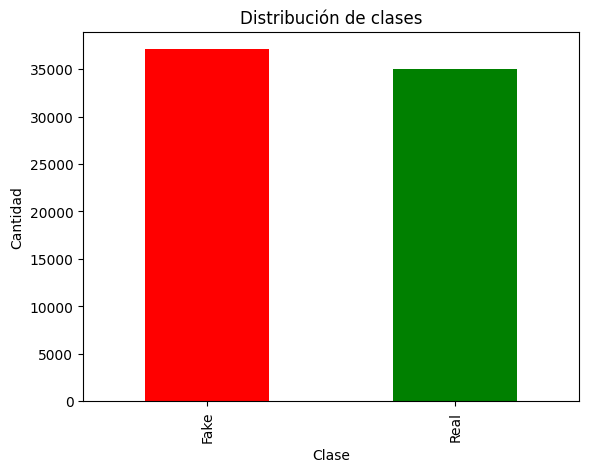

label
1    0.514404
0    0.485596
Name: proportion, dtype: float64


In [50]:
# RETO 1.2 — Distribucion de clases
# Cuenta noticias Reales (0) y Falsas (1)
class_counts = df['label'].value_counts()
print(class_counts)
# Crea grafica de barras con colores distintos por clase
class_counts.plot(kind='bar', color=['red', 'green'])
class_names = {0: 'Real', 1: 'Fake'}
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad')

plt.show()

print(df['label'].value_counts(normalize=True))
# Responde: Esta balanceado el dataset?

El dataset esta balanceado


=== Estadisticas de texto por clase ===
  Real: media=577.6, mediana=427.0, min=0, max=14641
  Fake: media=505.6, mediana=369.0, min=0, max=24234

=== Estadisticas de titulo por clase ===
  Real: media=11.0, mediana=11.0, min=2, max=30
  Fake: media=13.3, mediana=13.0, min=1, max=72

=== Longitud del Titulo (en palabras) ===
  Media:   12.2
  Mediana: 12.0
  Minimo:  1
  Maximo:  72
=== Longitud del TEXTO (en palabras) ===
  Media:   540.6
  Mediana: 398.0
  Minimo:  0
  Maximo:  24234


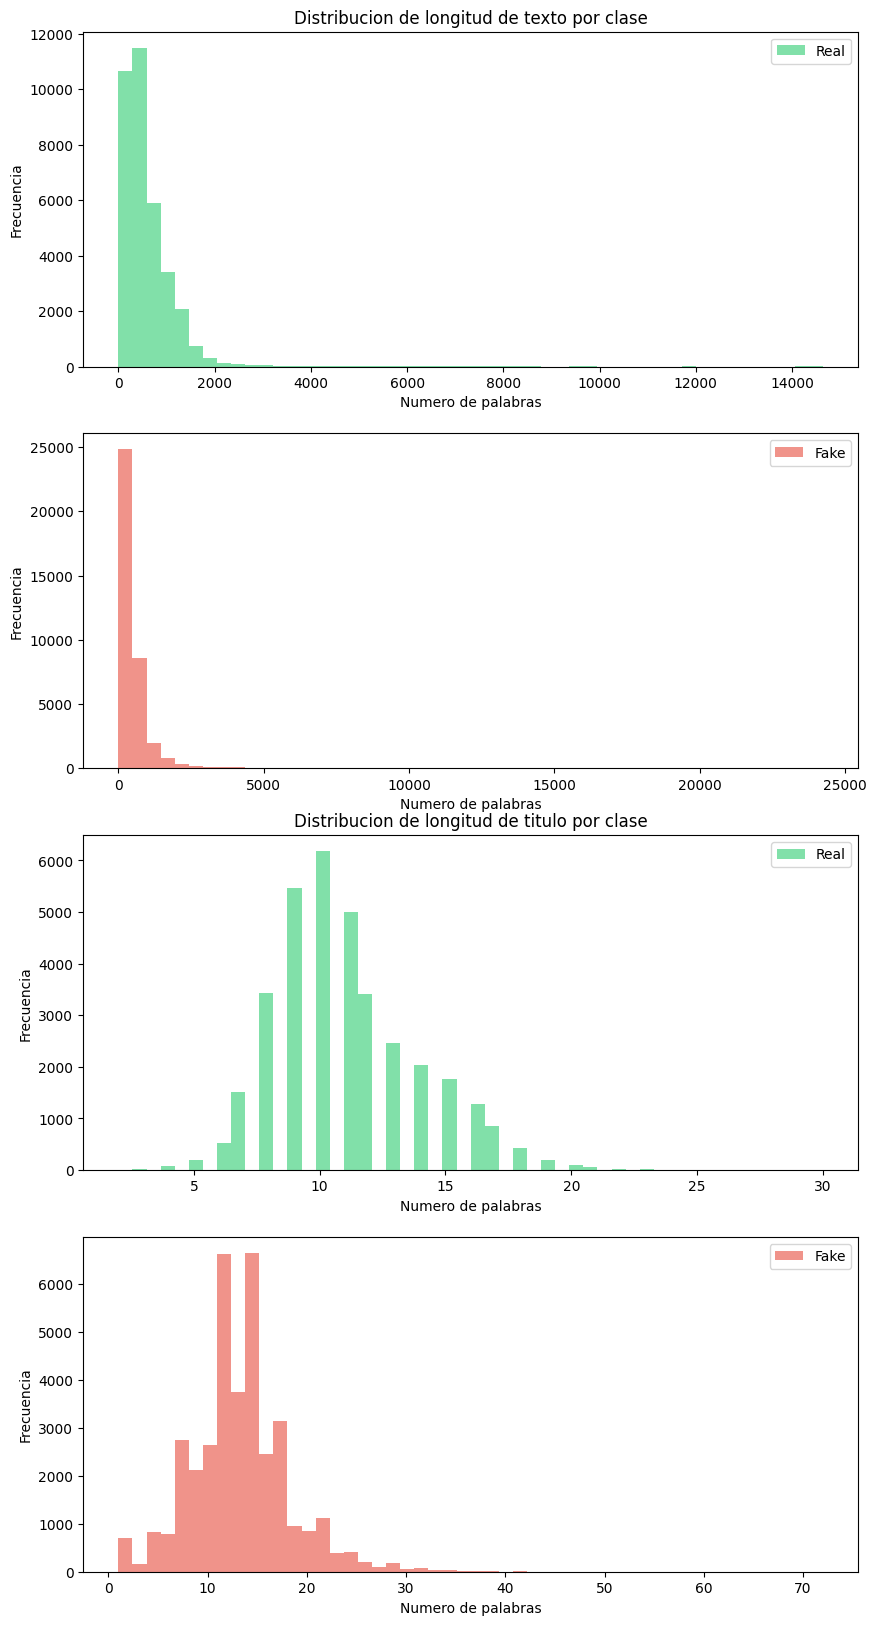

In [51]:
# RETO 1.3 — Distribucion de longitudes
# Calcula longitud en palabras para 'title' y 'text'
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
df['title_len'] = df['title'].apply(lambda x: len(str(x).split()))

# Estadisticas descriptivas
print(f'\n=== Estadisticas de texto por clase ===')
for label, name in class_names.items():
    subset = df[df['label'] == label]['text_len']
    print(f'  {name}: media={subset.mean():.1f}, mediana={subset.median():.1f}, '
          f'min={subset.min()}, max={subset.max()}')
    
print(f'\n=== Estadisticas de titulo por clase ===')
for label, name in class_names.items():
    subset = df[df['label'] == label]['title_len']
    print(f'  {name}: media={subset.mean():.1f}, mediana={subset.median():.1f}, '
          f'min={subset.min()}, max={subset.max()}')
# Crea histogramas por clase (Real vs Fake)

fig, axes = plt.subplots(4,1,figsize=(10, 20))

subset = df[df['label'] == 0]['text_len']
axes[0].hist(subset, bins=50, alpha=0.6, label='Real',color='#2ecc71')
axes[0].set_xlabel('Numero de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de longitud de texto por clase')
axes[0].legend()

subset = df[df['label'] == 1]['text_len']
axes[1].hist(subset, bins=50, alpha=0.6, label='Fake',color='#e74c3c')
axes[1].set_xlabel('Numero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

subset = df[df['label'] == 0]['title_len']
axes[2].hist(subset, bins=50, alpha=0.6, label='Real',color='#2ecc71')
axes[2].set_xlabel('Numero de palabras')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribucion de longitud de titulo por clase')
axes[2].legend()

subset = df[df['label'] == 1]['title_len']
axes[3].hist(subset, bins=50, alpha=0.6, label='Fake',color='#e74c3c')
axes[3].set_xlabel('Numero de palabras')
axes[3].set_ylabel('Frecuencia')
axes[3].legend()

# Imprime media, mediana, min, max de cada campo
print('\n=== Longitud del Titulo (en palabras) ===')
print(f"  Media:   {df['title_len'].mean():.1f}")
print(f"  Mediana: {df['title_len'].median():.1f}")
print(f"  Minimo:  {df['title_len'].min()}")
print(f"  Maximo:  {df['title_len'].max()}")

print('=== Longitud del TEXTO (en palabras) ===')
print(f"  Media:   {df['text_len'].mean():.1f}")
print(f"  Mediana: {df['text_len'].median():.1f}")
print(f"  Minimo:  {df['text_len'].min()}")
print(f"  Maximo:  {df['text_len'].max()}")

In [52]:
# RETO 1.4 — Valores nulos
# Detecta valores nulos por columna
print('Valores nulos por columna:')
null_counts = df.isnull().sum()
print(null_counts)
print(f'\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}')
print(f'Porcentaje del dataset: {df.isnull().any(axis=1).sum() / len(df) * 100:.2f}%')

empty_texts = (df['text'].str.strip() == '').sum()
print(f'\nTextos vacios (cadena vacia): {empty_texts}')

# Decide: eliminar filas o rellenar con cadena vacia?
rows_before = len(df)

# Rellenar nulos con cadena vacia
df['text'] = df['text'].fillna('')

# Eliminar filas con texto vacio (no aportan informacion)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)

rows_after = len(df)
print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')
# Implementa tu decision y documenta la justificacion

Valores nulos por columna:
title        558
text          39
label          0
text_len       0
title_len      0
dtype: int64

Total de filas con al menos un nulo: 597
Porcentaje del dataset: 0.83%

Textos vacios (cadena vacia): 744
Filas antes: 72,134
Filas despues: 71,351
Filas eliminadas: 783
Nulos restantes: 558


se eliminaron los que tienen nulos en el texto ya que el texto es la parte mas importante y sin este no se puede realizar un correcto analisis, decidi mantener los que no tienen titulo ya que a pesar de no tenerlo si tienen texto se puede trabajar con esto a mi parecer

In [53]:
# RETO 1.5 — Duplicados
# Detecta filas duplicadas (por title + text)
duplicates = df.duplicated(subset=['text'], keep='first')
n_duplicates = duplicates.sum()
print(f'Filas duplicadas encontradas: {n_duplicates:,}')
print(f'Porcentaje del dataset: {n_duplicates / len(df) * 100:.2f}%')

# Elimina duplicados conservando la primera aparicion
rows_before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
rows_after = len(df)

# Verifica si el balance de clases cambio

print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')

print(f'\nDistribucion de clases despues de eliminar duplicados:')
for label, count in df['label'].value_counts().items():
    name = class_names[label]
    print(f'  {name}: {count:,} ({count/len(df)*100:.1f}%)')

Filas duplicadas encontradas: 8,636
Porcentaje del dataset: 12.10%
Filas antes: 71,351
Filas despues: 62,715
Filas eliminadas: 8,636

Distribucion de clases despues de eliminar duplicados:
  Real: 34,620 (55.2%)
  Fake: 28,095 (44.8%)


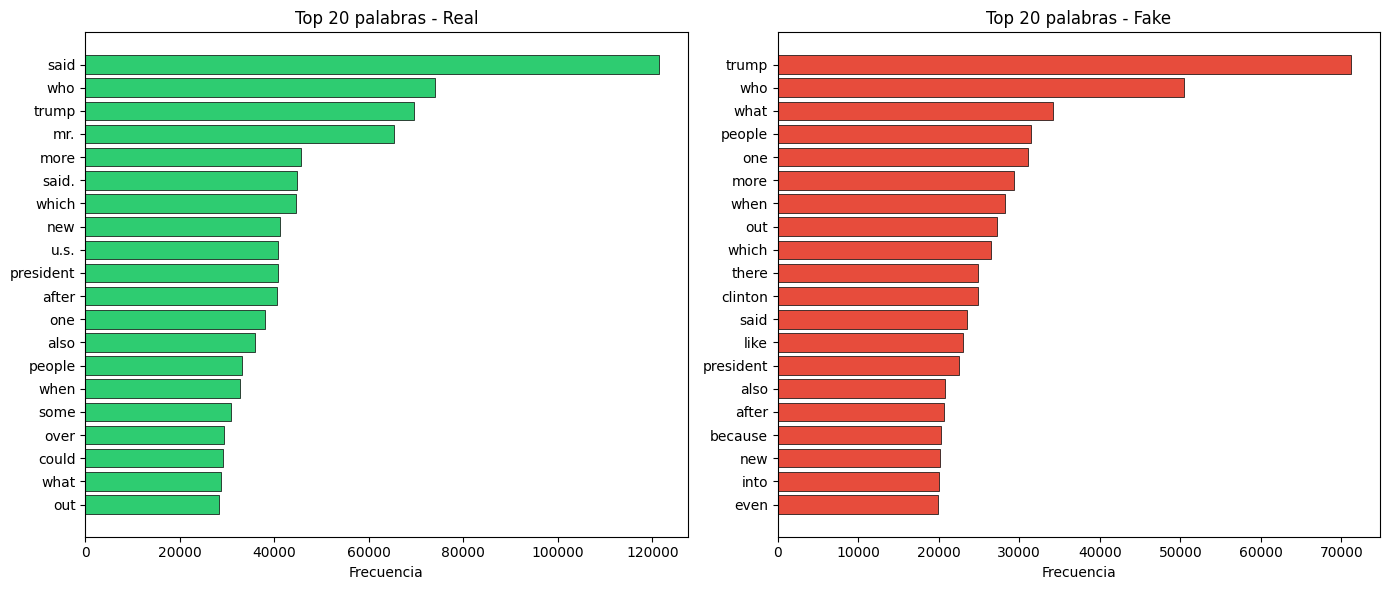

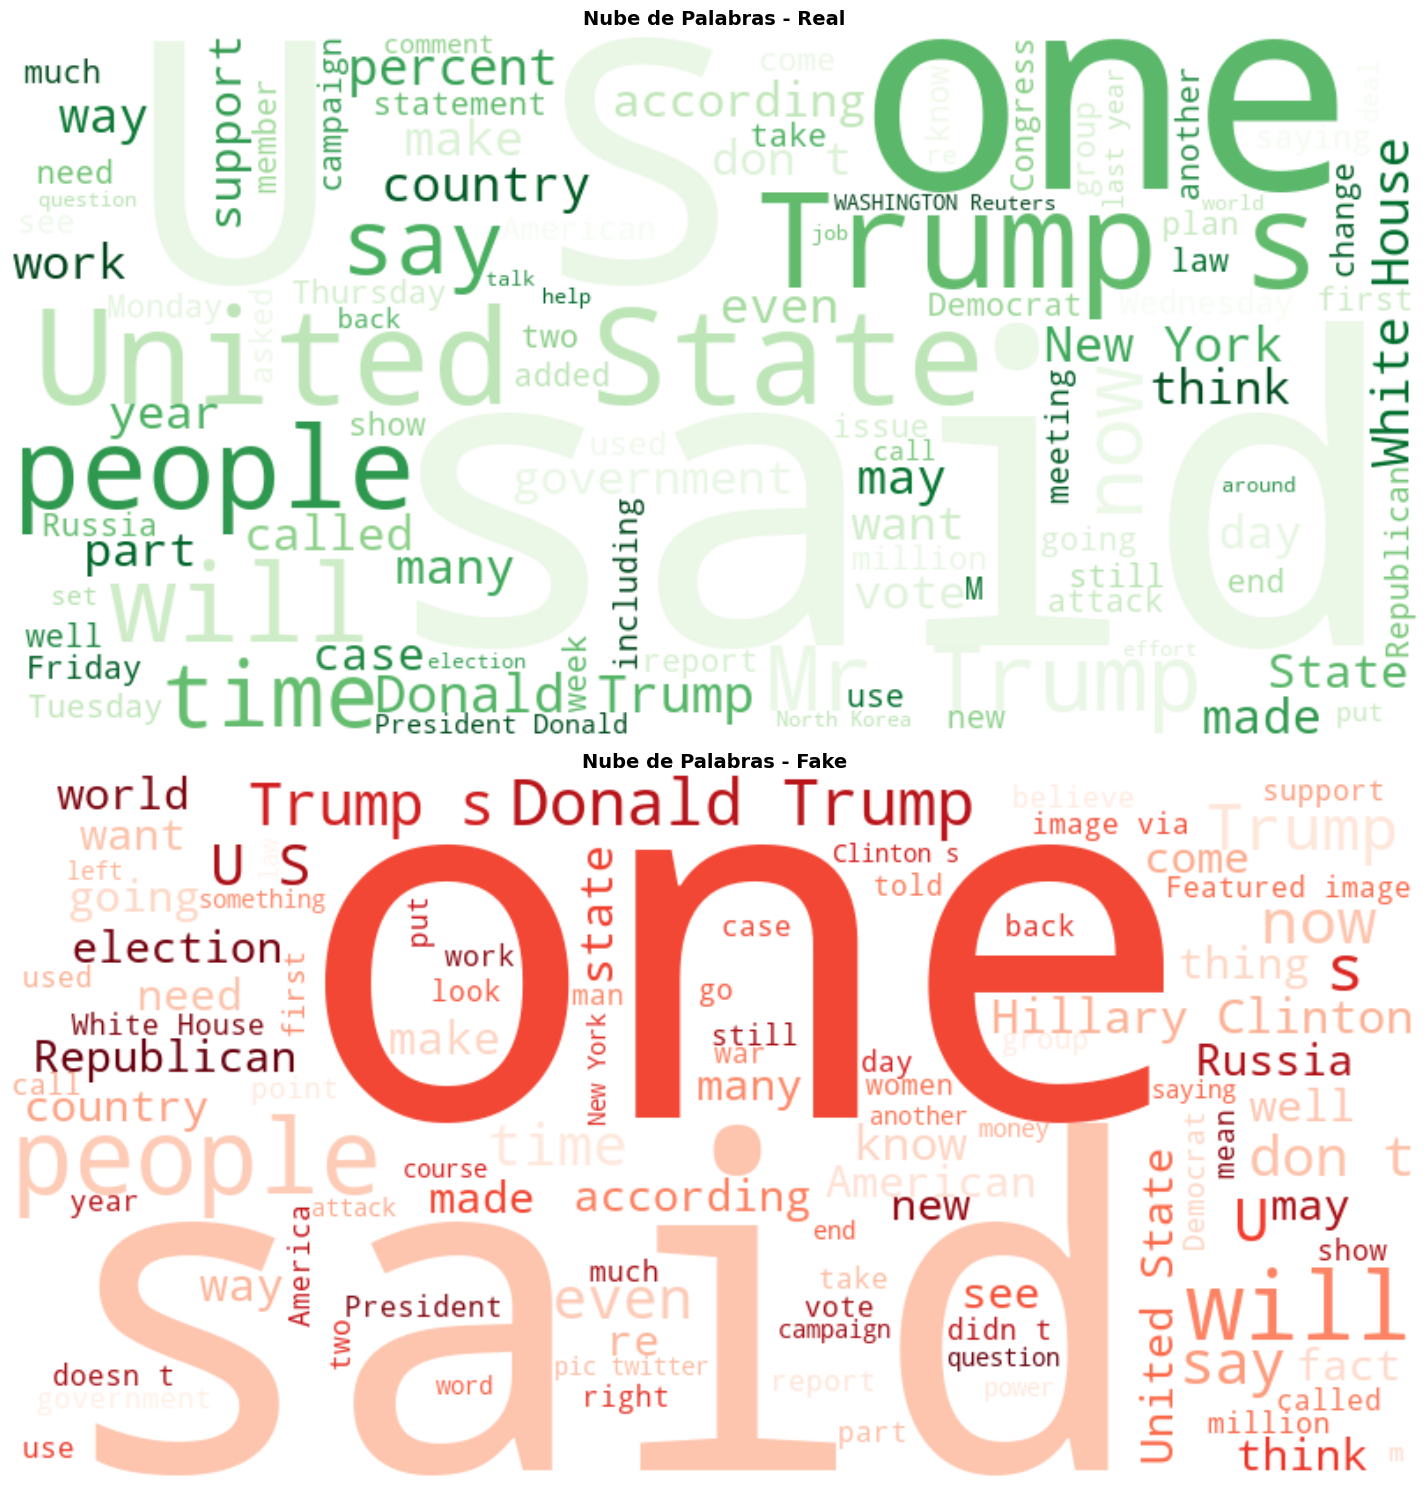

In [ ]:
# RETO 1.6 — Nubes de palabras
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (label, name) in enumerate(class_names.items()):
    # Contar todas las palabras de la clase
    all_text = ' '.join(df[df['label'] == label]['text'].str.lower().values)
    word_counts = Counter(all_text.split())

    # Top 20 (excluyendo stopwords comunes)
    stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
                 'to', 'of', 'in', 'for', 'and', 'on', 'that', 'it', 'with',
                 'as', 'at', 'by', 'from', 'or', 'this', 'but', 'not', 'have',
                 'has', 'had', 'i', 'he', 'she', 'they', 'we', 'you', 'my',
                 'his', 'her', 'its', 'our', 'their', 'if', 'do', 'did', 'would',
                 'will', 'can', 'just', 'about', 'so', 'than', 'no', 'all'}
    filtered = {w: c for w, c in word_counts.items()
                if w not in stopwords and len(w) > 2}
    top_20 = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:20]
    words, counts = zip(*top_20)

    color = '#2ecc71' if label == 0 else '#e74c3c'
    axes[idx].barh(range(len(words)), counts[::-1], color=color, edgecolor='black', linewidth=0.5)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words[::-1])
    axes[idx].set_xlabel('Frecuencia')
    axes[idx].set_title(f'Top 20 palabras - {name}')

plt.tight_layout()
plt.show()

stopwords = set(STOPWORDS)

#posibles palabras que se pueden agregar a las stopwords
#stopwords.update([
#    'said', 'say', 'also', 'one', 'new', 'people',
#    'who', 'what', 'when', 'where', 'would',
#    'could', 'us', 'mr', 'president'
#])

# Genera una nube de palabras para noticias Reales
fig, axes = plt.subplots(2, 1, figsize=(20, 15))

colors_map = {0: 'Greens', 1: 'Reds'}
for idx, (label, name) in enumerate(class_names.items()):
    text = ' '.join(df[df['label'] == label]['text'].astype(str).values)
    wordcloud = WordCloud(
        width=800, height=400,
        max_words=100,
        background_color='white',
        colormap=colors_map[label],
        stopwords=stopwords,
        random_state=42
    ).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras - {name}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
# Genera una nube de palabras para noticias Falsas
# Muestra ambas en subplots lado a lado
# Pregunta: Que diferencias observas entre las dos nubes?

In [ ]:
# RETO 1.7 — Pregunta de reflexion
# Calcula que porcentaje de textos tienen mas de 200 palabras
# Esto nos ayudara a elegir max_len para la red neuronal
pct = (df['text_len'] > 200).mean() * 100
print(f"Textos con mas de 200 palabras: {pct:.1f}%")

print(df['text_len'].describe())
p95 = np.percentile(df['text_len'], 95)
print(f"95% de los textos tienen menos de {int(p95)} palabras")
#se puede probar para ver en que punto se maximiza el rendimiento

Textos con mas de 200 palabras: 79.4%
count    62715.000000
mean       549.009902
std        610.058685
min          1.000000
25%        244.000000
50%        406.000000
75%        679.000000
max      24234.000000
Name: text_len, dtype: float64
95% de los textos tienen menos de 1404 palabras


---
## Preguntas de Reflexion sobre el Analisis Exploratorio de Datos

Responde las siguientes 10 preguntas en una celda markdown debajo de cada una. Tus respuestas deben estar fundamentadas en los resultados obtenidos durante el EDA.

**1.** ¿Por que es importante realizar un EDA antes de entrenar cualquier modelo de machine learning? ¿Que problemas podrian surgir si nos saltamos este paso?

**2.** Al analizar la distribucion de clases, ¿encontraste que el dataset esta balanceado o desbalanceado? ¿Como afectaria un desbalance severo (por ejemplo 90/10) al entrenamiento de un clasificador? ¿Que tecnicas conoces para mitigarlo?

**3.** Observando las distribuciones de longitud del texto, ¿las noticias falsas tienden a ser mas largas o mas cortas que las reales? ¿Que hipotesis podrias formular sobre por que existe esa diferencia?

**4.** Si eligieras un `max_len=200` palabras para truncar los textos antes de alimentar una red neuronal, ¿que porcentaje de informacion se perderia? ¿Como decidiras el valor optimo de `max_len` considerando el trade-off entre informacion y costo computacional?

**5.** ¿Que estrategia elegiste para manejar los valores nulos y por que? ¿En que escenarios seria mejor rellenar con un texto especial en lugar de eliminar las filas? ¿Y viceversa?

**6.** El dataset WELFake tenia aproximadamente un 11.7% de duplicados. ¿Por que es critico eliminarlos antes de dividir en conjuntos de entrenamiento y prueba? ¿Que sucederia con las metricas de evaluacion si no lo hicieramos?

**7.** ¿Que limitaciones tiene el EDA que realizamos? Menciona al menos dos aspectos del texto que NO exploramos y que podrian ser relevantes para la clasificacion (por ejemplo: estructura de oraciones, uso de signos de puntuacion, sentimiento, etc.).

**8.** Reflexiona sobre el impacto social de las noticias falsas. ¿Por que es importante que como ingenieros desarrollemos herramientas para detectarlas? ¿Que responsabilidad etica conlleva construir un clasificador de este tipo? ¿Que sucede si el modelo comete errores (falsos positivos vs falsos negativos)?

**9.** Considerando todo lo aprendido en este EDA, ¿que caracteristicas (features) del texto crees que seran mas utiles para que un modelo distinga entre noticias reales y falsas? ¿Crees que el titulo, el cuerpo del texto, o ambos seran mas informativos? Justifica tu respuesta con base en los datos explorados.

### Escribe tus respuestas aqui:

**R1.**


**R2.**


**R3.**


**R4.**


**R5.**


**R6.**


**R7.**


**R8.**


**R9.**


**R10.**